In [91]:
# Importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

In [92]:
df_usa = df[df['job_country'] == 'United States'].copy()

In [93]:
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.strftime('%B')

In [94]:
df_usa_pivot = df_usa.pivot_table(index= 'job_posted_month', columns= 'job_title_short', aggfunc= 'size')

In [95]:
df_usa_pivot.reset_index(inplace= True)
df_usa_pivot['month_no'] = pd.to_datetime(df_usa_pivot['job_posted_month'], format= '%B').dt.month
df_usa_pivot.sort_values('month_no', inplace= True)
df_usa_pivot.set_index('job_posted_month', inplace= True)
df_usa_pivot.drop(columns= 'month_no', inplace= True)


In [98]:
top_3 = df_usa['job_title_short'].value_counts().head(3)
top_3 = top_3.index.to_list()

In [101]:
df_usa_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


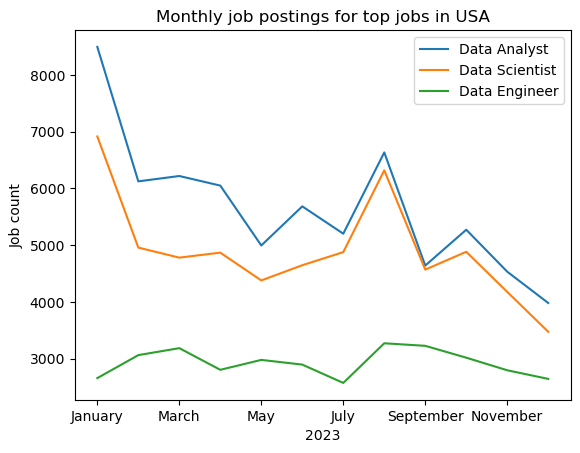

In [100]:
df_usa_pivot[top_3].plot(kind= 'line')
plt.xlabel('2023')
plt.ylabel('Job count')
plt.title('Monthly job postings for top jobs in USA')
plt.legend()
plt.show()